In [ ]:
#printing all spectrum
import numpy as np
import matplotlib.pyplot as plt
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
import astropy_healpix as ah
import desi_retriever.dr1 as dr1

objects = [
    (150.7622, 1.8690, 39627829536620822),
]

SURVEY_PROGRAMS = [
    ("main", "dark"),
    ("main", "bright"),
    ("sv3", "dark"),
    ("sv3", "bright"),
    ("sv1", "dark"),
    ("sv1", "bright"),
]

def radec_to_hpx(ra, dec, nside=64):
    """Convert RA/Dec to DESI HEALPix pixel (Nside=64, nested)."""
    return ah.lonlat_to_healpix(
        ra * u.deg, dec * u.deg,
        nside=nside, order='nested'
    )

def stitch_arms(spec):
    """Concatenate b/r/z arms into a single wave/flux/sigma array."""
    arms = ['b', 'r', 'z']
    waves, fluxes, sigmas = [], [], []
    for arm in arms:
        w = spec.get(f'{arm}_wavelength')
        f = spec.get(f'{arm}_flux')
        iv = spec.get(f'{arm}_ivar')
        if w is None or f is None:
            continue
        waves.append(w)
        fluxes.append(f)
        if iv is not None:
            sig = np.zeros_like(iv)
            mask = iv > 0
            sig[mask] = 1.0 / np.sqrt(iv[mask])
            sig[~mask] = np.nan
        else:
            sig = np.full_like(f, np.nan)
        sigmas.append(sig)

    if not waves:
        return None, None, None

    # Sort by wavelength to stitch cleanly
    wave = np.concatenate(waves)
    flux = np.concatenate(fluxes)
    sigma = np.concatenate(sigmas)
    order = np.argsort(wave)
    return wave[order], flux[order], sigma[order]


def get_desi_spectrum(ra, dec, targetid):
    hpx = radec_to_hpx(ra, dec)
    print(f"Computed HEALPix: {hpx}")

    for survey, program in SURVEY_PROGRAMS:
        try:
            specs = dr1.get_specs(
                survey=survey,
                program=program,
                hpx=int(hpx),
                targetid=targetid,
                ivar=True,           # <-- required to get ivar back
            )
            if not specs:
                print(f"  [{survey}/{program}] No spectra returned.")
                continue

            spec = specs[0]
            wave, flux, sigma = stitch_arms(spec)
            if wave is None:
                print(f"  [{survey}/{program}] Could not extract wave/flux.")
                continue

            print(f"  [{survey}/{program}] Success! {len(wave)} pixels.")
            return wave, flux, sigma, survey, program

        except Exception as e:
            print(f"  [{survey}/{program}] Exception: {e}")
            continue

    return None, None, None, None, None


# ----------------------------
# Main loop
# ----------------------------
for ra, dec, tid in objects:
    # ---------- SDSS ----------
    pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
    xid = SDSS.query_region(pos, spectro=True, radius=2 * u.arcsec)
    sdss_wave = sdss_flux = sdss_err = None

    if xid is not None and len(xid) > 0:
        spectra = SDSS.get_spectra(matches=xid)
        if spectra:
            spec = spectra[0][1].data
            sdss_wave = 10 ** spec["loglam"]
            sdss_flux = spec["flux"]
            if "ivar" in spec.names:
                ivar = spec["ivar"]
                sdss_err = np.zeros_like(ivar)
                mask = ivar > 0
                sdss_err[mask] = 1 / np.sqrt(ivar[mask])
                sdss_err[~mask] = np.nan

    # ---------- DESI ----------
    desi_wave, desi_flux, desi_sigma, survey, program = get_desi_spectrum(ra, dec, tid)

    # ---------- Plot ----------
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    if desi_wave is not None:
        valid = np.isfinite(desi_sigma)
        axs[0].plot(desi_wave, desi_flux, color="purple", lw=0.8, label="flux")
        if valid.any():
            axs[0].fill_between(
                desi_wave, desi_flux - desi_sigma, desi_flux + desi_sigma,
                where=valid, color="lavender", alpha=0.4, label="±1σ"
            )
        axs[0].set_title(f"DESI ({survey}/{program})\nTARGETID {tid}")
        axs[0].set_xlabel("Wavelength [Å]")
        axs[0].set_ylabel("Flux [10⁻¹⁷ erg/s/cm²/Å]")
        axs[0].legend()
    else:
        axs[0].text(0.5, 0.5, "No DESI spectrum found", ha='center', va='center',
                    transform=axs[0].transAxes, fontsize=12)
        axs[0].set_title("DESI — Not Found")

    if sdss_wave is not None:
        valid = np.isfinite(sdss_err) if sdss_err is not None else np.zeros(len(sdss_wave), dtype=bool)
        axs[1].plot(sdss_wave, sdss_flux, color="green", lw=0.8, label="flux")
        if valid.any():
            axs[1].fill_between(
                sdss_wave, sdss_flux - sdss_err, sdss_flux + sdss_err,
                where=valid, color="lightgreen", alpha=0.4, label="±1σ"
            )
        axs[1].set_title(f"SDSS Spectrum\nRA={ra}, Dec={dec}")
        axs[1].set_xlabel("Wavelength [Å]")
        axs[1].set_ylabel("Flux [10⁻¹⁷ erg/s/cm²/Å]")
        axs[1].legend()
    else:
        axs[1].text(0.5, 0.5, "No SDSS spectrum found", ha='center', va='center',
                    transform=axs[1].transAxes, fontsize=12)
        axs[1].set_title("SDSS — Not Found")

    plt.suptitle(f"RA={ra}, Dec={dec} | TARGETID {tid}", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"spectrum_{tid}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [10]:
pip install astropy_healpix

Note: you may need to restart the kernel to use updated packages.


Computed HEALPix: 27256
https://data.desi.lbl.gov/public/dr1//spectro/redux/iron/healpix/main/dark/272/27256/coadd-main-dark-27256.fits
  [main/dark] Success! 7958 pixels.


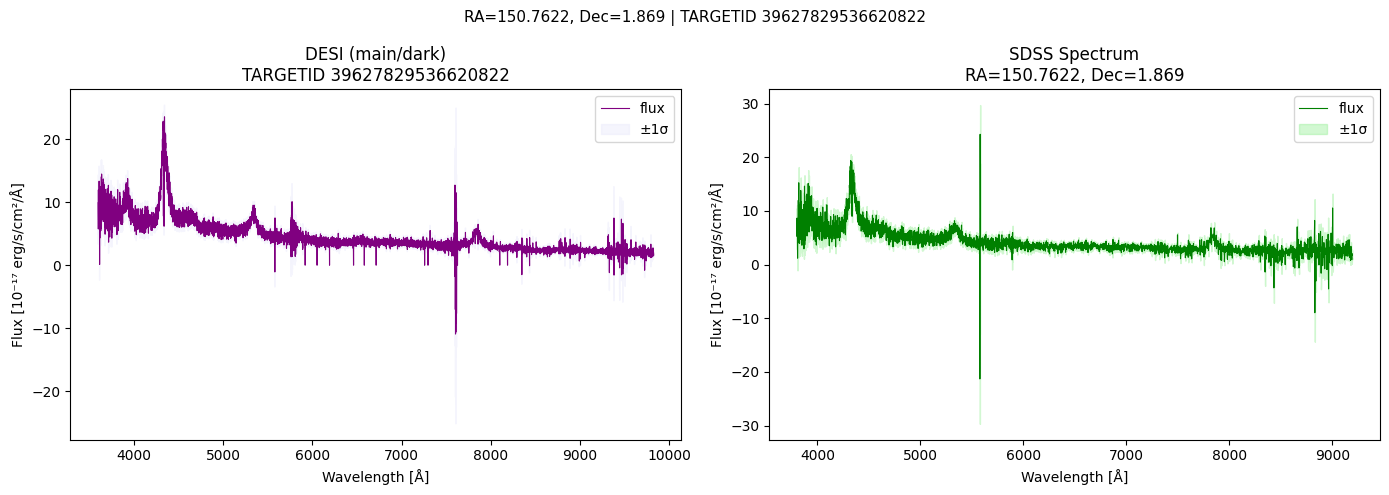

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
import astropy_healpix as ah
import desi_retriever.dr1 as dr1

objects = [
    (150.7622, 1.8690, 39627829536620822),
]

SURVEY_PROGRAMS = [
    ("main", "dark"),
    ("main", "bright"),
    ("sv3", "dark"),
    ("sv3", "bright"),
    ("sv1", "dark"),
    ("sv1", "bright"),
]

def radec_to_hpx(ra, dec, nside=64):
    """Convert RA/Dec to DESI HEALPix pixel (Nside=64, nested)."""
    return ah.lonlat_to_healpix(
        ra * u.deg, dec * u.deg,
        nside=nside, order='nested'
    )

def stitch_arms(spec):
    """Concatenate b/r/z arms into a single wave/flux/sigma array."""
    arms = ['b', 'r', 'z']
    waves, fluxes, sigmas = [], [], []
    for arm in arms:
        w = spec.get(f'{arm}_wavelength')
        f = spec.get(f'{arm}_flux')
        iv = spec.get(f'{arm}_ivar')
        if w is None or f is None:
            continue
        waves.append(w)
        fluxes.append(f)
        if iv is not None:
            sig = np.zeros_like(iv)
            mask = iv > 0
            sig[mask] = 1.0 / np.sqrt(iv[mask])
            sig[~mask] = np.nan
        else:
            sig = np.full_like(f, np.nan)
        sigmas.append(sig)

    if not waves:
        return None, None, None

    # Sort by wavelength to stitch cleanly
    wave = np.concatenate(waves)
    flux = np.concatenate(fluxes)
    sigma = np.concatenate(sigmas)
    order = np.argsort(wave)
    return wave[order], flux[order], sigma[order]


def get_desi_spectrum(ra, dec, targetid):
    hpx = radec_to_hpx(ra, dec)
    print(f"Computed HEALPix: {hpx}")

    for survey, program in SURVEY_PROGRAMS:
        try:
            specs = dr1.get_specs(
                survey=survey,
                program=program,
                hpx=int(hpx),
                targetid=targetid,
                ivar=True,           # <-- required to get ivar back
            )
            if not specs:
                print(f"  [{survey}/{program}] No spectra returned.")
                continue

            spec = specs[0]
            wave, flux, sigma = stitch_arms(spec)
            if wave is None:
                print(f"  [{survey}/{program}] Could not extract wave/flux.")
                continue

            print(f"  [{survey}/{program}] Success! {len(wave)} pixels.")
            return wave, flux, sigma, survey, program

        except Exception as e:
            print(f"  [{survey}/{program}] Exception: {e}")
            continue

    return None, None, None, None, None


# ----------------------------
# Main loop
# ----------------------------
for ra, dec, tid in objects:
    # ---------- SDSS ----------
    pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
    xid = SDSS.query_region(pos, spectro=True, radius=2 * u.arcsec)
    sdss_wave = sdss_flux = sdss_err = None

    if xid is not None and len(xid) > 0:
        spectra = SDSS.get_spectra(matches=xid)
        if spectra:
            spec = spectra[0][1].data
            sdss_wave = 10 ** spec["loglam"]
            sdss_flux = spec["flux"]
            if "ivar" in spec.names:
                ivar = spec["ivar"]
                sdss_err = np.zeros_like(ivar)
                mask = ivar > 0
                sdss_err[mask] = 1 / np.sqrt(ivar[mask])
                sdss_err[~mask] = np.nan

    # ---------- DESI ----------
    desi_wave, desi_flux, desi_sigma, survey, program = get_desi_spectrum(ra, dec, tid)

    # ---------- Plot ----------
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    if desi_wave is not None:
        valid = np.isfinite(desi_sigma)
        axs[0].plot(desi_wave, desi_flux, color="purple", lw=0.8, label="flux")
        if valid.any():
            axs[0].fill_between(
                desi_wave, desi_flux - desi_sigma, desi_flux + desi_sigma,
                where=valid, color="lavender", alpha=0.4, label="±1σ"
            )
        axs[0].set_title(f"DESI ({survey}/{program})\nTARGETID {tid}")
        axs[0].set_xlabel("Wavelength [Å]")
        axs[0].set_ylabel("Flux [10⁻¹⁷ erg/s/cm²/Å]")
        axs[0].legend()
    else:
        axs[0].text(0.5, 0.5, "No DESI spectrum found", ha='center', va='center',
                    transform=axs[0].transAxes, fontsize=12)
        axs[0].set_title("DESI — Not Found")

    if sdss_wave is not None:
        valid = np.isfinite(sdss_err) if sdss_err is not None else np.zeros(len(sdss_wave), dtype=bool)
        axs[1].plot(sdss_wave, sdss_flux, color="green", lw=0.8, label="flux")
        if valid.any():
            axs[1].fill_between(
                sdss_wave, sdss_flux - sdss_err, sdss_flux + sdss_err,
                where=valid, color="lightgreen", alpha=0.4, label="±1σ"
            )
        axs[1].set_title(f"SDSS Spectrum\nRA={ra}, Dec={dec}")
        axs[1].set_xlabel("Wavelength [Å]")
        axs[1].set_ylabel("Flux [10⁻¹⁷ erg/s/cm²/Å]")
        axs[1].legend()
    else:
        axs[1].text(0.5, 0.5, "No SDSS spectrum found", ha='center', va='center',
                    transform=axs[1].transAxes, fontsize=12)
        axs[1].set_title("SDSS — Not Found")

    plt.suptitle(f"RA={ra}, Dec={dec} | TARGETID {tid}", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"spectrum_{tid}.png", dpi=150, bbox_inches="tight")
    plt.show()

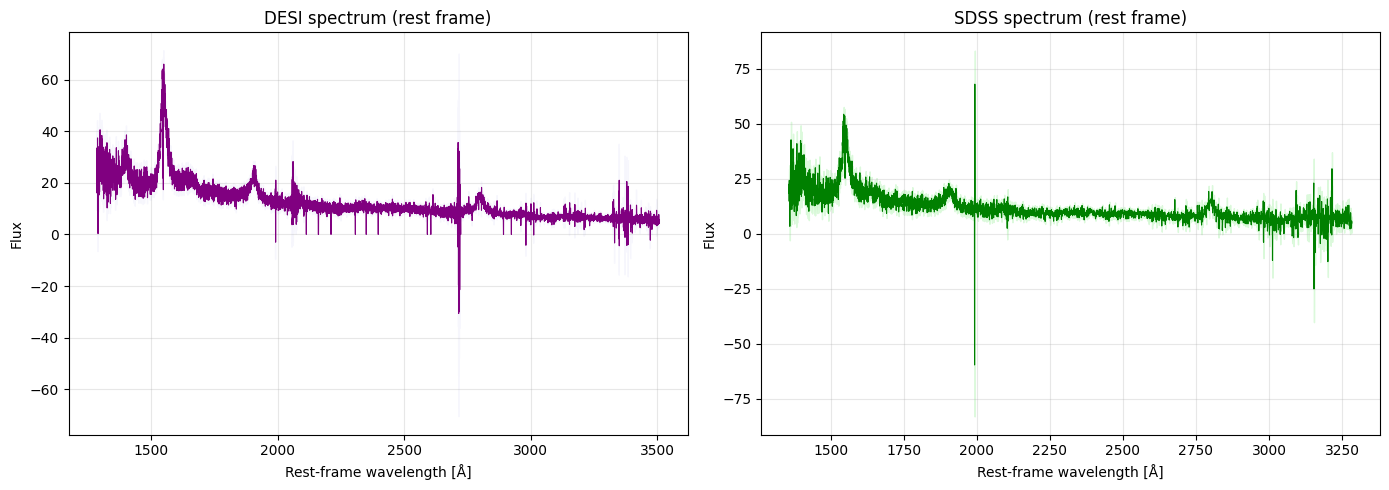

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
import astropy.units as u


# -----------------------------
# Inputs
# -----------------------------
DESI_FILE = "coadd-main-dark-27256.fits"
TARGETID  = 39627829536620822
RA  = 150.7622
DEC = 1.8690
z = 1.8   # redshift


# -----------------------------
# Load DESI spectrum
# -----------------------------
hdul = fits.open(DESI_FILE)

fibermap = hdul["FIBERMAP"].data
idx = np.where(fibermap["TARGETID"] == TARGETID)[0]
if len(idx) == 0:
    raise RuntimeError("TARGETID not found in DESI file")

i = idx[0]

desi_wave = np.concatenate([
    hdul["B_WAVELENGTH"].data,
    hdul["R_WAVELENGTH"].data,
    hdul["Z_WAVELENGTH"].data,
])

desi_flux = np.concatenate([
    hdul["B_FLUX"].data[i],
    hdul["R_FLUX"].data[i],
    hdul["Z_FLUX"].data[i],
])

desi_ivar = np.concatenate([
    hdul["B_IVAR"].data[i],
    hdul["R_IVAR"].data[i],
    hdul["Z_IVAR"].data[i],
])

desi_err = np.full_like(desi_ivar, np.nan)
m = desi_ivar > 0
desi_err[m] = 1.0 / np.sqrt(desi_ivar[m])


# -----------------------------
# Rest-frame correction (DESI)
# -----------------------------
desi_wave_rest = desi_wave / (1 + z)
desi_flux_rest = desi_flux * (1 + z)
desi_err_rest  = desi_err  * (1 + z)


# -----------------------------
# Load SDSS spectrum
# -----------------------------
pos = SkyCoord(RA, DEC, unit="deg", frame="icrs")
xid = SDSS.query_region(pos, spectro=True, radius=2 * u.arcsec)

sdss_wave_rest = sdss_flux_rest = sdss_err_rest = None

if xid is not None:
    specs = SDSS.get_spectra(matches=xid)
    if specs:
        spec = specs[0][1].data

        sdss_wave = 10 ** spec["loglam"]
        sdss_flux = spec["flux"]

        if "ivar" in spec.names:
            ivar = spec["ivar"]
            sdss_err = np.full_like(ivar, np.nan)
            m = ivar > 0
            sdss_err[m] = 1.0 / np.sqrt(ivar[m])
        else:
            sdss_err = None

        # -----------------------------
        # Rest-frame correction (SDSS)
        # -----------------------------
        sdss_wave_rest = sdss_wave / (1 + z)
        sdss_flux_rest = sdss_flux * (1 + z)
        if sdss_err is not None:
            sdss_err_rest = sdss_err * (1 + z)


# -----------------------------
# Plot side-by-side (rest frame)
# -----------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# DESI
axs[0].plot(desi_wave_rest, desi_flux_rest, lw=0.8, color="purple")
axs[0].fill_between(
    desi_wave_rest,
    desi_flux_rest - desi_err_rest,
    desi_flux_rest + desi_err_rest,
    alpha=0.3,
    color="lavender"
)
axs[0].set_title("DESI spectrum (rest frame)")
axs[0].set_xlabel("Rest-frame wavelength [Å]")
axs[0].set_ylabel("Flux")
axs[0].grid(alpha=0.3)

# SDSS
if sdss_wave_rest is not None:
    axs[1].plot(sdss_wave_rest, sdss_flux_rest, lw=0.8, color="green")
    if sdss_err_rest is not None:
        axs[1].fill_between(
            sdss_wave_rest,
            sdss_flux_rest - sdss_err_rest,
            sdss_flux_rest + sdss_err_rest,
            alpha=0.3,
            color="lightgreen"
        )
    axs[1].set_title(f"SDSS spectrum (rest frame)")
    axs[1].set_xlabel("Rest-frame wavelength [Å]")
    axs[1].set_ylabel("Flux")
    axs[1].grid(alpha=0.3)
else:
    axs[1].set_title("No SDSS spectrum found")

plt.tight_layout()
plt.show()


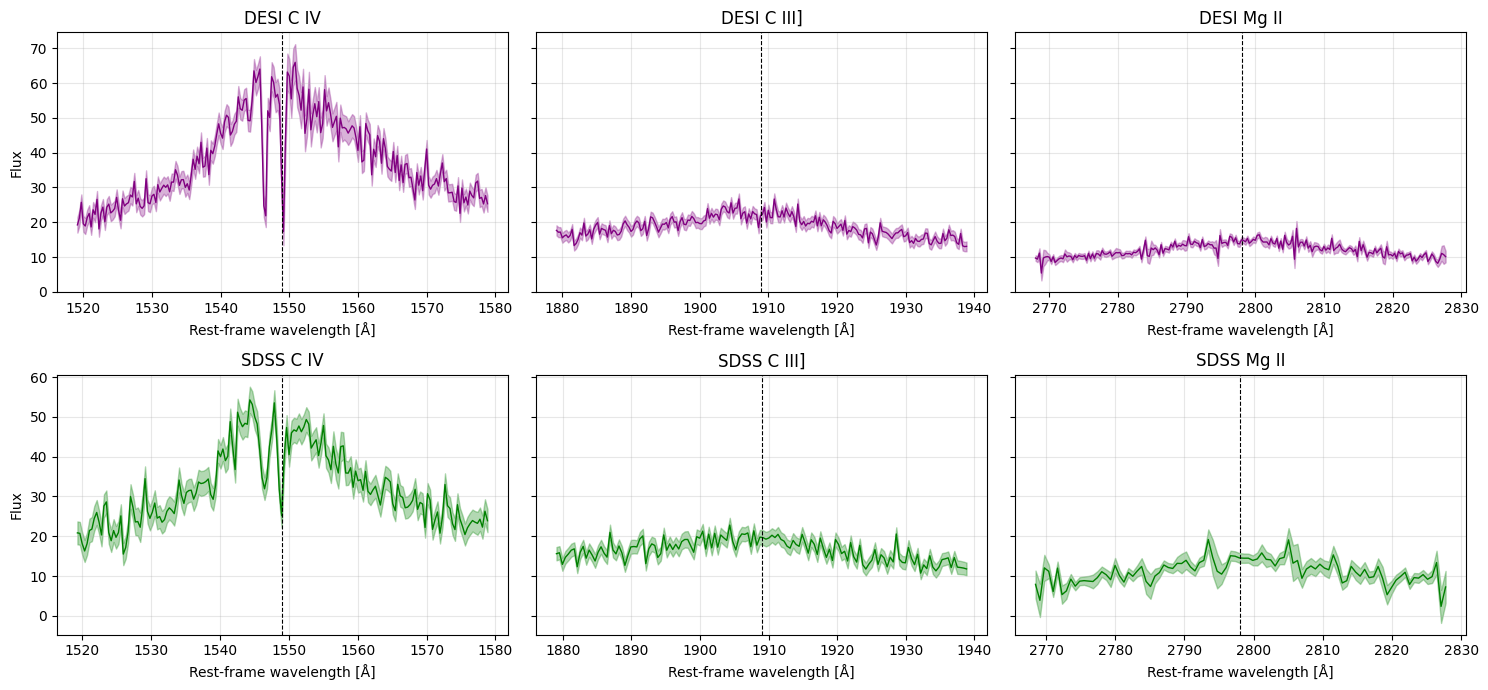

In [13]:
DESI_FILE = "coadd-main-dark-27256.fits"
TARGETID  = 39627829536620822
RA  = 150.7622
DEC = 1.8690
z= 1.8

LINES = {
    "C IV": 1549.0,
    "C III]": 1909.0,
    "Mg II": 2798.0
}

WINDOW = 30  # Å on each side


# -----------------------------
# Rest-frame correction
# -----------------------------
desi_wave_rest = desi_wave / (1 + z)
sdss_wave_rest = sdss_wave / (1 + z)

desi_flux_rest = desi_flux * (1 + z)
sdss_flux_rest = sdss_flux * (1 + z)

desi_err_rest = desi_err * (1 + z)
sdss_err_rest = sdss_err * (1 + z)


# -----------------------------
# Zoom plotting function
# -----------------------------
def plot_zoom(ax, wave, flux, err, line_wave, color, title):
    mask = (wave > line_wave - WINDOW) & (wave < line_wave + WINDOW)

    if not np.any(mask):
        ax.set_title(f"{title}\n(no data)")
        return

    ax.plot(wave[mask], flux[mask], color=color, lw=1)

    if err is not None:
        ax.fill_between(
            wave[mask],
            flux[mask] - err[mask],
            flux[mask] + err[mask],
            color=color,
            alpha=0.3
        )

    ax.axvline(line_wave, color="k", ls="--", lw=0.8)
    ax.set_xlabel("Rest-frame wavelength [Å]")
    ax.set_title(title)
    ax.grid(alpha=0.3)


# -----------------------------
# Plot grid
# -----------------------------
fig, axs = plt.subplots(2, 3, figsize=(15, 7), sharey="row")

line_items = list(LINES.items())

# ---------- DESI (top row) ----------
for j, (name, lwave) in enumerate(line_items):
    plot_zoom(
        axs[0, j],
        desi_wave_rest,
        desi_flux_rest,
        desi_err_rest,
        lwave,
        color="purple",
        title=f"DESI {name}"
    )

# ---------- SDSS (bottom row) ----------
for j, (name, lwave) in enumerate(line_items):
    plot_zoom(
        axs[1, j],
        sdss_wave_rest,
        sdss_flux_rest,
        sdss_err_rest,
        lwave,
        color="green",
        title=f"SDSS {name}"
    )

axs[0, 0].set_ylabel("Flux")
axs[1, 0].set_ylabel("Flux")

plt.tight_layout()
plt.show()



================ SDSS FITS ================

[C IV]
  μ = 1549.58 Å
  σ = 10.84 Å
  Flux = 6.297e+02

[C III]
  μ = 1904.13 Å
  σ = 15.18 Å
  Flux = 2.656e+02

[Mg II]
  μ = 2799.02 Å
  σ = 10.56 Å
  Flux = 1.520e+02

SDSS [C III]/[C IV] = 0.422

================ DESI FITS ================

[C IV]
  μ = 1551.10 Å
  σ = 12.45 Å
  Flux = 9.865e+02

[C III]
  μ = 1905.80 Å
  σ = 12.36 Å
  Flux = 2.400e+02

[Mg II]
  μ = 2799.25 Å
  σ = 12.89 Å
  Flux = 1.757e+02

DESI [C III]/[C IV] = 0.243


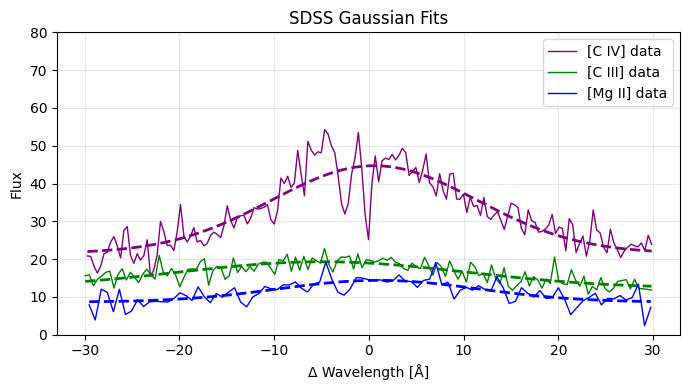

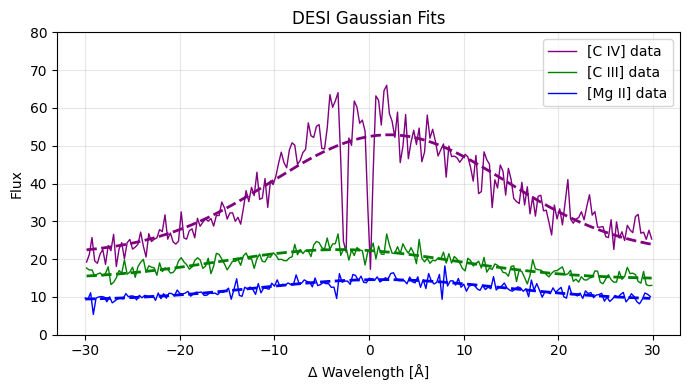

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
from scipy.optimize import minimize

# ============================================================
# Common Inputs
# ============================================================
DESI_FILE = "coadd-main-dark-27256.fits"
TARGETID  = 39627829536620822
RA  = 150.7622
DEC = 1.8690
z= 1.8

LINES = {
    "[C IV]": 1549.0,
    "[C III]": 1909.0,
    "[Mg II]": 2798.0
}

WINDOW = 30
colors = {"[C IV]": "purple", "[C III]": "green", "[Mg II]": "blue"}


# ============================================================
# Gaussian model + chi-square
# ============================================================
def gaussian_model(w, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((w - mu) / sigma)**2) + C

def chi2(params, w, f, e):
    A, mu, sigma, C = params
    model = gaussian_model(w, A, mu, sigma, C)
    return np.sum(((f - model) / e)**2)

def fit_emission_line(w, f, e, mu_guess):

    A0 = np.nanmax(f) - np.nanmedian(f)
    sigma0 = 3.0
    C0 = np.nanmedian(f)

    p0 = [A0, mu_guess, sigma0, C0]

    bounds = [
        (0, None),
        (mu_guess - 5, mu_guess + 5),
        (0.5, 20),
        (0, None)
    ]

    result = minimize(chi2, p0, args=(w, f, e), bounds=bounds)

    if not result.success:
        raise RuntimeError("Gaussian fit failed")

    A, mu, sigma, C = result.x

    flux = A * sigma * np.sqrt(2*np.pi)

    return {
        "A": A,
        "mu": mu,
        "sigma": sigma,
        "baseline": C,
        "flux": flux
    }


# ============================================================
# ===================== SDSS SECTION ========================
# ============================================================
print("\n================ SDSS FITS ================")

co = coords.SkyCoord(RA, DEC, unit=(u.deg, u.deg))
sp = SDSS.get_spectra(coordinates=co, radius=2*u.arcsec)

if len(sp) == 0:
    raise RuntimeError("No SDSS spectrum found")

hdul_sdss = sp[0]

sdss_flux = hdul_sdss[1].data["flux"]
sdss_wave = 10**hdul_sdss[1].data["loglam"]
sdss_ivar = hdul_sdss[1].data["ivar"]

sdss_err = np.zeros_like(sdss_ivar)
good = sdss_ivar > 0
sdss_err[good] = 1 / np.sqrt(sdss_ivar[good])

# Rest-frame
sdss_wave_rest = sdss_wave / (1 + z)
sdss_flux_rest = sdss_flux * (1 + z)
sdss_err_rest  = sdss_err  * (1 + z)

sdss_results = {}

for name, line_wave in LINES.items():

    delta = sdss_wave_rest - line_wave
    mask = (delta > -WINDOW) & (delta < WINDOW)

    if not np.any(mask):
        continue

    w = sdss_wave_rest[mask]
    f = sdss_flux_rest[mask]
    e = sdss_err_rest[mask]

    good = np.isfinite(f) & np.isfinite(e)
    w, f, e = w[good], f[good], e[good]

    sdss_results[name] = fit_emission_line(w, f, e, line_wave)

# Print SDSS results
for name, res in sdss_results.items():
    print(f"\n{name}")
    print(f"  μ = {res['mu']:.2f} Å")
    print(f"  σ = {res['sigma']:.2f} Å")
    print(f"  Flux = {res['flux']:.3e}")

print(f"\nSDSS [C III]/[C IV] = {sdss_results['[C III]']['flux']/sdss_results['[C IV]']['flux']:.3f}")


# ---- SDSS Plot ----
fig1, ax1 = plt.subplots(figsize=(7,4))

for name, line_wave in LINES.items():

    delta = sdss_wave_rest - line_wave
    mask = (delta > -WINDOW) & (delta < WINDOW)

    w = delta[mask]
    f = sdss_flux_rest[mask]

    ax1.plot(w, f, lw=1, color=colors[name], label=f"{name} data")

    res = sdss_results[name]
    model = gaussian_model(
        sdss_wave_rest[mask],
        res["A"], res["mu"], res["sigma"], res["baseline"]
    )

    ax1.plot(w, model, ls="--", color=colors[name], lw=2)

ax1.set_ylim(0,80)
ax1.set_xlabel("Δ Wavelength [Å]")
ax1.set_ylabel("Flux")
ax1.set_title("SDSS Gaussian Fits")
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()


# ============================================================
# ===================== DESI SECTION ========================
# ============================================================
print("\n================ DESI FITS ================")

hdul = fits.open(DESI_FILE)
fibermap = hdul["FIBERMAP"].data
idx = np.where(fibermap["TARGETID"] == TARGETID)[0]

if len(idx) == 0:
    raise RuntimeError("TARGETID not found")

i = idx[0]

desi_wave = np.concatenate([
    hdul["B_WAVELENGTH"].data,
    hdul["R_WAVELENGTH"].data,
    hdul["Z_WAVELENGTH"].data
])

desi_flux = np.concatenate([
    hdul["B_FLUX"].data[i],
    hdul["R_FLUX"].data[i],
    hdul["Z_FLUX"].data[i]
])

desi_ivar = np.concatenate([
    hdul["B_IVAR"].data[i],
    hdul["R_IVAR"].data[i],
    hdul["Z_IVAR"].data[i]
])

desi_err = np.zeros_like(desi_ivar)
good = desi_ivar > 0
desi_err[good] = 1 / np.sqrt(desi_ivar[good])

# Rest-frame
desi_wave_rest = desi_wave / (1 + z)
desi_flux_rest = desi_flux * (1 + z)
desi_err_rest  = desi_err  * (1 + z)

desi_results = {}

for name, line_wave in LINES.items():

    delta = desi_wave_rest - line_wave
    mask = (delta > -WINDOW) & (delta < WINDOW)

    w = desi_wave_rest[mask]
    f = desi_flux_rest[mask]
    e = desi_err_rest[mask]

    good = np.isfinite(f) & np.isfinite(e)
    w, f, e = w[good], f[good], e[good]

    desi_results[name] = fit_emission_line(w, f, e, line_wave)

# Print DESI results
for name, res in desi_results.items():
    print(f"\n{name}")
    print(f"  μ = {res['mu']:.2f} Å")
    print(f"  σ = {res['sigma']:.2f} Å")
    print(f"  Flux = {res['flux']:.3e}")

print(f"\nDESI [C III]/[C IV] = {desi_results['[C III]']['flux']/desi_results['[C IV]']['flux']:.3f}")


# ---- DESI Plot ----
fig2, ax2 = plt.subplots(figsize=(7,4))

for name, line_wave in LINES.items():

    delta = desi_wave_rest - line_wave
    mask = (delta > -WINDOW) & (delta < WINDOW)

    w = delta[mask]
    f = desi_flux_rest[mask]

    ax2.plot(w, f, lw=1, color=colors[name], label=f"{name} data")

    res = desi_results[name]
    model = gaussian_model(
        desi_wave_rest[mask],
        res["A"], res["mu"], res["sigma"], res["baseline"]
    )

    ax2.plot(w, model, ls="--", color=colors[name], lw=2)

ax2.set_ylim(0,80)
ax2.set_xlabel("Δ Wavelength [Å]")
ax2.set_ylabel("Flux")
ax2.set_title("DESI Gaussian Fits")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

IndexError: boolean index did not match indexed array along axis 0; size of axis is 3837 but size of corresponding boolean axis is 7958

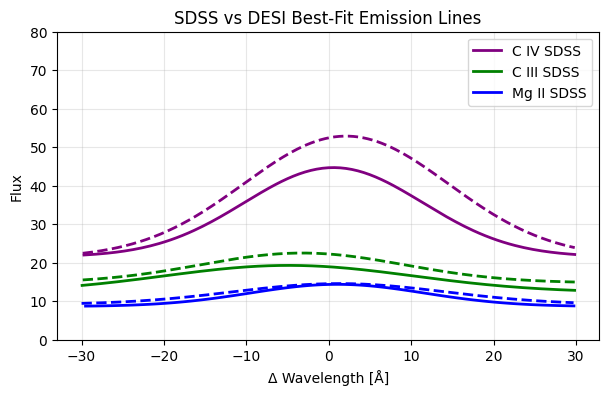

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
from astropy.io import fits

# ============================================================
# Inputs
# ============================================================
RA, DEC = 150.7622, 1.8690
z = 1.8
DESI_FILE = "coadd-main-dark-27256.fits"
TARGETID  = 39627829536620822

LINES = {
    "C IV": 1549.0,
    "C III": 1909.0,
    "Mg II": 2798.0
}
WINDOW = 30

# ============================================================
# Gaussian + chi²
# ============================================================
def gaussian_model(w, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((w - mu) / sigma)**2) + C

def chi2(p, w, f, e):
    return np.sum(((f - gaussian_model(w, *p)) / e)**2)

def fit_line(w, f, e, mu0):
    p0 = [np.nanmax(f) - np.nanmedian(f), mu0, 3.0, np.nanmedian(f)]
    bounds = [(0,None),(mu0-5,mu0+5),(0.5,20),(0,None)]
    res = minimize(chi2, p0, args=(w,f,e), bounds=bounds)
    if not res.success:
        raise RuntimeError("Fit failed")
    A, mu, sigma, C = res.x
    return {"A":A, "mu":mu, "sigma":sigma, "baseline":C}

# ============================================================
# -------- SDSS --------
# ============================================================
co = coords.SkyCoord(RA, DEC, unit="deg")
sp = SDSS.get_spectra(coordinates=co, radius=2*u.arcsec)[0]

sdss_flux = sp[1].data["flux"].copy()
sdss_wave = (10**sp[1].data["loglam"]).copy()
sdss_ivar = sp[1].data["ivar"].copy()

sdss_err = np.full_like(sdss_ivar, np.nan)
m = sdss_ivar > 0
sdss_err[m] = 1 / np.sqrt(sdss_ivar[m])

sdss_wave /= (1+z)
sdss_flux *= (1+z)
sdss_err  *= (1+z)

sdss_fits = {}
for name, lw in LINES.items():
    d = sdss_wave - lw
    m = (d>-WINDOW)&(d<WINDOW)&np.isfinite(sdss_err)
    sdss_fits[name] = fit_line(sdss_wave[m], sdss_flux[m], sdss_err[m], lw)

# ============================================================
# -------- DESI --------
# ============================================================
hdul = fits.open(DESI_FILE)
i = np.where(hdul["FIBERMAP"].data["TARGETID"]==TARGETID)[0][0]

desi_wave = np.concatenate([hdul[f"{b}_WAVELENGTH"].data.copy() for b in "BRZ"])
desi_flux = np.concatenate([hdul[f"{b}_FLUX"].data[i].copy() for b in "BRZ"])
desi_ivar = np.concatenate([hdul[f"{b}_IVAR"].data[i].copy() for b in "BRZ"])

desi_err = np.full_like(desi_ivar, np.nan)
m = desi_ivar > 0
desi_err[m] = 1 / np.sqrt(desi_ivar[m])

desi_wave /= (1+z)
desi_flux *= (1+z)
desi_err  *= (1+z)

desi_fits = {}
for name, lw in LINES.items():
    d = desi_wave - lw
    m = (d>-WINDOW)&(d<WINDOW)&np.isfinite(desi_err)
    desi_fits[name] = fit_line(desi_wave[m], desi_flux[m], desi_err[m], lw)

# ============================================================
# -------- COMBINED PLOT --------
# ============================================================
fig, ax = plt.subplots(figsize=(7,4))
colors = {"C IV":"purple","C III":"green","Mg II":"blue"}

for name, lw in LINES.items():

    # SDSS
    d = sdss_wave - lw
    m = (d>-WINDOW)&(d<WINDOW)
    r = sdss_fits[name]
    ax.plot(
        d[m],
        gaussian_model(sdss_wave[m], r["A"], r["mu"], r["sigma"], r["baseline"]),
        color=colors[name], lw=2, label=f"{name} SDSS"
    )

    # DESI (no duplicate label)
    d = desi_wave - lw
    m = (d>-WINDOW)&(d<WINDOW)
    r = desi_fits[name]
    ax.plot(
        d[m],
        gaussian_model(desi_wave[m], r["A"], r["mu"], r["sigma"], r["baseline"]),
        color=colors[name], lw=2, ls="--"
    )
ax.set_xlabel("Δ Wavelength [Å]")
ax.set_ylabel("Flux")
ax.set_ylim(0,80)
ax.set_title("SDSS vs DESI Best-Fit Emission Lines")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()